# Classifying Alzheimer's Disease Using Deep Learning on fMRI
## Graph Neural Networks (GCN, GAT, GraphSAGE)

**Student:** Kirankumar Chikkamankanala Somashekar
**Date:** August 26, 2026 | **Version:** v1
**Baseline to beat:** SVM Linear = 71.3% accuracy, 0.777 AUC-ROC
**Dataset:** 262 subjects (131 AD, 131 CN), 132 ROIs

**Key change (Keith's feedback):** Include original FC signal alongside GCN convolutional layers via skip connection.

---
**Contents:**
1. Setup
2. Data Loading
3. Graph Construction
4. Model Architectures (with skip connection)
5. Training Engine
6. Experiments
7. Results and Comparison
8. Save All Results

## 1. Setup

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch_geometric -q

import numpy as np
import pandas as pd
import pickle, os, copy, time, warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool, global_max_pool
from torch_geometric.utils import dense_to_sparse

from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix, roc_curve, auc)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':300,'font.size':11,
                     'axes.titlesize':13,'axes.titleweight':'bold','savefig.bbox':'tight'})

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Mounted at /content/drive
Device: cuda | PyTorch: 2.11.0+cu128


In [ ]:
BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data'
RESULTS_BASE = '/content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results'
NB_RESULTS = os.path.join(RESULTS_BASE, 'nb02_gcn')
NB_FIGURES = os.path.join(NB_RESULTS, 'figures')
os.makedirs(NB_RESULTS, exist_ok=True)
os.makedirs(NB_FIGURES, exist_ok=True)
print(f'Data: {BASE}\nResults: {NB_RESULTS}')

Data: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/data
Results: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb02_gcn


## 2. Data Loading

In [ ]:
fc_matrices = np.load(f'{BASE}/fc_matrices_stacked.npy')  # (262,132,132)
y = np.load(f'{BASE}/y_labels.npy')                        # (262,)
subject_ids = np.load(f'{BASE}/subject_ids.npy', allow_pickle=True)

with open(f'{BASE}/cv_folds.pkl','rb') as f: cv_folds = pickle.load(f)
with open(os.path.join(RESULTS_BASE,'nb01_baseline','baseline_results.pkl'),'rb') as f:
    baseline_results = pickle.load(f)

N, M = fc_matrices.shape[0], fc_matrices.shape[1]
print(f'Subjects: {N}, ROIs: {M}, CN: {(y==0).sum()}, AD: {(y==1).sum()}')
print(f'FC range: [{fc_matrices.min():.3f}, {fc_matrices.max():.3f}]')
print(f'Baseline SVM Linear: {baseline_results["svm_linear"]["accuracy_mean"]:.4f}')

Subjects: 262, ROIs: 132, CN: 131, AD: 131
FC range: [-1.119, 2.705]
Baseline SVM Linear: 0.7134


## 3. Graph Construction

### Design choices (fixes from previous attempts):
- **Absolute FC values** as edge weights (no negative weights)
- **KNN or threshold** sparsification (no dense 17K-edge graphs)
- **Normalised** edge weights to [0,1]
- **Node features** = normalised FC profile (132-dim per node)

In [ ]:
def build_graphs(fc_mats, labels, method='knn', k=10, threshold=0.2, binary=False):
    """
    Convert FC matrices to PyG graphs.
    method: 'knn' or 'threshold'
    """
    graphs = []
    for i in range(len(fc_mats)):
        fc = np.abs(fc_mats[i].copy())
        np.fill_diagonal(fc, 0)
        fc = np.clip(fc, 0, 3.0)

        # Node features = normalised FC profile
        x = fc / (fc.max() + 1e-8)
        x = torch.tensor(x, dtype=torch.float32)  # (132, 132)

        # Build adjacency
        if method == 'knn':
            adj = np.zeros_like(fc)
            for row in range(fc.shape[0]):
                top_k = np.argsort(fc[row])[-k:]
                adj[row, top_k] = fc[row, top_k]
            adj = np.maximum(adj, adj.T)  # symmetric
        else:  # threshold
            adj = fc.copy()
            adj[adj < threshold] = 0

        if adj.max() > 0: adj = adj / adj.max()
        if binary: adj = (adj > 0).astype(float)

        adj_t = torch.tensor(adj, dtype=torch.float32)
        edge_index, edge_attr = dense_to_sparse(adj_t)
        y_t = torch.tensor([int(labels[i])], dtype=torch.long)
        graphs.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_t))
    return graphs

print('Graph construction function defined.')

Graph construction function defined.


In [ ]:
# Build graph variants
print('Building graphs...')
g_knn10 = build_graphs(fc_matrices, y, method='knn', k=10)
g_knn10_bin = build_graphs(fc_matrices, y, method='knn', k=10, binary=True)
g_thresh02 = build_graphs(fc_matrices, y, method='threshold', threshold=0.2)

# Verify
for name, gl in [('KNN-10',g_knn10),('KNN-10 binary',g_knn10_bin),('Thresh 0.2',g_thresh02)]:
    nans = sum(1 for g in gl if torch.isnan(g.x).any())
    edges = gl[0].edge_index.shape[1]
    print(f'  {name}: edges={edges}, NaN={nans}')
print('Done.')

Building graphs...
  KNN-10: edges=1754, NaN=0
  KNN-10 binary: edges=1754, NaN=0
  Thresh 0.2: edges=8980, NaN=0
Done.


## 4. Model Architectures (with Skip Connection)

### Keith's feedback:
> *"Are you including the original signal along with the convolutional layers?"*

The new architecture concatenates the **raw FC profile** (projected to hidden-dim) with the
**GCN-learned features** before pooling. This gives the classifier access to both the original
connectivity patterns AND the graph-learned representations.

In [ ]:
class BrainGCN_Skip(nn.Module):
    """
    GCN with skip connection from input to classifier.
    Per Keith's feedback: include original signal alongside convolutions.

    Architecture:
      GCN path:   x -> [GCNConv -> BN -> ReLU -> Drop] x L -> x_conv
      Skip path:  x -> Linear(in, hidden) -> x_skip
      Combined:   concat(x_conv, x_skip) -> pooling -> classifier
    """
    def __init__(self, in_ch, hidden, n_classes=2, n_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout

        # GCN path
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(GCNConv(in_ch, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers - 1):
            self.convs.append(GCNConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))

        # Skip connection: project original features to hidden dim
        self.skip_proj = nn.Linear(in_ch, hidden)
        self.skip_bn = nn.BatchNorm1d(hidden)

        # Classifier: takes conv + skip (both mean+max pooled)
        # conv: hidden*2, skip: hidden*2 -> total: hidden*4
        self.fc1 = nn.Linear(hidden * 4, hidden)
        self.bn_fc = nn.BatchNorm1d(hidden)
        self.fc2 = nn.Linear(hidden, n_classes)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch

        # Skip path: project and pool original features
        x_skip = F.relu(self.skip_bn(self.skip_proj(x)))
        x_skip = torch.cat([global_mean_pool(x_skip, batch),
                            global_max_pool(x_skip, batch)], dim=1)  # (B, hidden*2)

        # GCN path
        x_conv = x
        for conv, bn in zip(self.convs, self.bns):
            x_new = conv(x_conv, ei, edge_weight=ea)
            x_new = bn(x_new)
            x_new = F.relu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            if x_conv.shape == x_new.shape:
                x_conv = x_conv + x_new  # residual
            else:
                x_conv = x_new
        x_conv = torch.cat([global_mean_pool(x_conv, batch),
                            global_max_pool(x_conv, batch)], dim=1)  # (B, hidden*2)

        # Combine conv + skip
        x = torch.cat([x_conv, x_skip], dim=1)  # (B, hidden*4)

        x = F.relu(self.bn_fc(self.fc1(x)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.fc2(x)


class BrainGAT_Skip(nn.Module):
    """
    GAT with skip connection. Learns attention for each edge.
    """
    def __init__(self, in_ch, hidden, n_classes=2, n_layers=2, dropout=0.5, heads=4):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(GATConv(in_ch, hidden, heads=heads, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden * heads))
        for _ in range(n_layers - 1):
            self.convs.append(GATConv(hidden*heads, hidden, heads=1, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden))

        self.skip_proj = nn.Linear(in_ch, hidden)
        self.skip_bn = nn.BatchNorm1d(hidden)

        self.fc1 = nn.Linear(hidden * 4, hidden)
        self.bn_fc = nn.BatchNorm1d(hidden)
        self.fc2 = nn.Linear(hidden, n_classes)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch

        x_skip = F.relu(self.skip_bn(self.skip_proj(x)))
        x_skip = torch.cat([global_mean_pool(x_skip, batch),
                            global_max_pool(x_skip, batch)], dim=1)

        x_conv = x
        for conv, bn in zip(self.convs, self.bns):
            x_conv = conv(x_conv, ei)
            x_conv = bn(x_conv)
            x_conv = F.elu(x_conv)
            x_conv = F.dropout(x_conv, p=self.dropout, training=self.training)
        x_conv = torch.cat([global_mean_pool(x_conv, batch),
                            global_max_pool(x_conv, batch)], dim=1)

        x = torch.cat([x_conv, x_skip], dim=1)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.fc2(x)


class BrainSAGE_Skip(nn.Module):
    """GraphSAGE with skip connection."""
    def __init__(self, in_ch, hidden, n_classes=2, n_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.convs.append(SAGEConv(in_ch, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers-1):
            self.convs.append(SAGEConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))
        self.skip_proj = nn.Linear(in_ch, hidden)
        self.skip_bn = nn.BatchNorm1d(hidden)
        self.fc1 = nn.Linear(hidden*4, hidden)
        self.bn_fc = nn.BatchNorm1d(hidden)
        self.fc2 = nn.Linear(hidden, n_classes)
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x_skip = F.relu(self.skip_bn(self.skip_proj(x)))
        x_skip = torch.cat([global_mean_pool(x_skip, batch), global_max_pool(x_skip, batch)], dim=1)
        x_conv = x
        for conv, bn in zip(self.convs, self.bns):
            x_conv = F.relu(bn(conv(x_conv, ei)))
            x_conv = F.dropout(x_conv, p=self.dropout, training=self.training)
        x_conv = torch.cat([global_mean_pool(x_conv, batch), global_max_pool(x_conv, batch)], dim=1)
        x = torch.cat([x_conv, x_skip], dim=1)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.fc2(x)

# Parameter counts
for name, cls, kw in [('GCN+Skip', BrainGCN_Skip, {}),
                       ('GAT+Skip', BrainGAT_Skip, {'heads':4}),
                       ('SAGE+Skip', BrainSAGE_Skip, {})]:
    m = cls(in_ch=132, hidden=64, n_layers=2, **kw)
    print(f'{name}: {sum(p.numel() for p in m.parameters()):,} params')

GCN+Skip: 38,274 params
GAT+Skip: 77,122 params
SAGE+Skip: 50,818 params


## 5. Training Engine

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        if torch.isnan(out).any(): continue
        loss = criterion(out, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(1)==batch.y).sum().item()
        total += batch.num_graphs
    return total_loss/max(total,1), correct/max(total,1)

@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    preds, probs, labels, total_loss = [], [], [], 0
    crit = nn.CrossEntropyLoss()
    for batch in loader:
        batch = batch.to(device)
        out = model(batch)
        if torch.isnan(out).any(): out = torch.nan_to_num(out)
        total_loss += crit(out, batch.y).item() * batch.num_graphs
        p = F.softmax(out, dim=1)
        preds.extend(out.argmax(1).cpu().numpy())
        probs.extend(p[:,1].cpu().numpy())
        labels.extend(batch.y.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels), total_loss/len(loader.dataset)

print('Training functions defined.')

Training functions defined.


In [ ]:
def run_experiment(model_cls, model_kw, graphs, cv_folds, config, device):
    """Run 5-fold CV. Returns standardised results dict."""
    t_start = time.time()
    metrics = {k:[] for k in ['accuracy','f1','precision','recall','auc_roc']}
    all_true, all_pred, all_prob = [], [], []
    histories = []

    print(f'\n{"="*60}')
    print(f'{config["name"]}')
    print(f'{"="*60}')

    for fi, (tr_idx, te_idx) in enumerate(cv_folds):
        tr_ld = DataLoader([graphs[i] for i in tr_idx], batch_size=config['bs'], shuffle=True)
        te_ld = DataLoader([graphs[i] for i in te_idx], batch_size=config['bs'], shuffle=False)

        model = model_cls(**model_kw).to(device)
        opt = Adam(model.parameters(), lr=config['lr'], weight_decay=config['wd'])
        crit = nn.CrossEntropyLoss()
        sched = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=15)

        best_loss, best_state, wait = float('inf'), copy.deepcopy(model.state_dict()), 0
        hist = {'tl':[],'vl':[],'ta':[],'va':[]}

        for ep in range(config['epochs']):
            tl, ta = train_epoch(model, tr_ld, opt, crit, device)
            pr, pb, lb, vl = eval_model(model, te_ld, device)
            va = accuracy_score(lb, pr)
            hist['tl'].append(tl); hist['vl'].append(vl)
            hist['ta'].append(ta); hist['va'].append(va)
            sched.step(vl)
            if vl < best_loss:
                best_loss = vl; best_state = copy.deepcopy(model.state_dict()); wait = 0
            else: wait += 1
            if wait >= config['patience']: break

        model.load_state_dict(best_state)
        pr, pb, lb, _ = eval_model(model, te_ld, device)
        acc = accuracy_score(lb,pr); f1 = f1_score(lb,pr,average='macro',zero_division=0)
        prec = precision_score(lb,pr,average='macro',zero_division=0)
        rec = recall_score(lb,pr,average='macro',zero_division=0)
        try: auc_v = roc_auc_score(lb,pb)
        except: auc_v = 0.5

        for k,v in zip(metrics.keys(),[acc,f1,prec,rec,auc_v]): metrics[k].append(v)
        all_true.extend(lb.tolist()); all_pred.extend(pr.tolist()); all_prob.extend(pb.tolist())
        histories.append(hist)
        print(f'  Fold {fi+1}: Acc={acc:.4f} F1={f1:.4f} AUC={auc_v:.4f} Ep={len(hist["tl"])}')

    elapsed = time.time() - t_start
    res = {'model_name':config['name'], 'model_type':'gcn', 'n_subjects':N,
           'n_features':f'{M}x{M} graph', 'config':config,
           'training_time_seconds':elapsed, 'fold_histories':histories,
           'y_true_all':all_true, 'y_pred_all':all_pred, 'y_prob_all':all_prob,
           'date':datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
    for m in metrics:
        res[f'{m}_mean']=np.mean(metrics[m]); res[f'{m}_std']=np.std(metrics[m])
        res[f'{m}_per_fold']=metrics[m]

    print(f'  >> Acc={res["accuracy_mean"]:.4f}+/-{res["accuracy_std"]:.4f} '
          f'AUC={res["auc_roc_mean"]:.4f}+/-{res["auc_roc_std"]:.4f} ({elapsed:.0f}s)')
    return res

print('Experiment runner defined.')

Experiment runner defined.


## 6. Experiments

### 6.1 GCN with Skip Connection

In [ ]:
tc = {'bs':32, 'epochs':300, 'patience':30, 'lr':1e-3, 'wd':5e-4}
all_results = []

for gname, graphs in [('KNN-10',g_knn10), ('Thresh-0.2',g_thresh02)]:
    cfg = {**tc, 'name': f'GCN+Skip {gname} h64 L2'}
    r = run_experiment(BrainGCN_Skip, {'in_ch':M,'hidden':64,'n_layers':2,'dropout':0.5},
                       graphs, cv_folds, cfg, DEVICE)
    all_results.append(r)


GCN+Skip KNN-10 h64 L2
  Fold 1: Acc=0.5094 F1=0.3375 AUC=0.4160 Ep=31
  Fold 2: Acc=0.4906 F1=0.3291 AUC=0.6937 Ep=37
  Fold 3: Acc=0.8269 F1=0.8263 AUC=0.8595 Ep=65
  Fold 4: Acc=0.5577 F1=0.4895 AUC=0.6050 Ep=31
  Fold 5: Acc=0.7115 F1=0.7062 AUC=0.7855 Ep=42
  >> Acc=0.6192+/-0.1297 AUC=0.6719+/-0.1540 (20s)

GCN+Skip Thresh-0.2 h64 L2
  Fold 1: Acc=0.7358 F1=0.7240 AUC=0.7749 Ep=40
  Fold 2: Acc=0.5849 F1=0.5726 AUC=0.7365 Ep=38
  Fold 3: Acc=0.7500 F1=0.7477 AUC=0.8491 Ep=63
  Fold 4: Acc=0.6154 F1=0.5938 AUC=0.6450 Ep=43
  Fold 5: Acc=0.6346 F1=0.6279 AUC=0.6953 Ep=37
  >> Acc=0.6642+/-0.0664 AUC=0.7401+/-0.0695 (28s)


### 6.2 GAT with Skip Connection

In [ ]:
for gname, graphs in [('KNN-10',g_knn10), ('KNN-10-bin',g_knn10_bin)]:
    cfg = {**tc, 'name': f'GAT+Skip {gname} h64 L2'}
    r = run_experiment(BrainGAT_Skip, {'in_ch':M,'hidden':64,'n_layers':2,'dropout':0.5,'heads':4},
                       graphs, cv_folds, cfg, DEVICE)
    all_results.append(r)


GAT+Skip KNN-10 h64 L2
  Fold 1: Acc=0.5094 F1=0.3375 AUC=0.5627 Ep=33
  Fold 2: Acc=0.6792 F1=0.6619 AUC=0.7650 Ep=43
  Fold 3: Acc=0.6923 F1=0.6919 AUC=0.7589 Ep=50
  Fold 4: Acc=0.6154 F1=0.5938 AUC=0.6746 Ep=42
  Fold 5: Acc=0.5000 F1=0.4319 AUC=0.5399 Ep=31
  >> Acc=0.5993+/-0.0815 AUC=0.6602+/-0.0948 (21s)

GAT+Skip KNN-10-bin h64 L2
  Fold 1: Acc=0.5660 F1=0.5426 AUC=0.6410 Ep=41
  Fold 2: Acc=0.6604 F1=0.6603 AUC=0.7422 Ep=44
  Fold 3: Acc=0.5962 F1=0.5339 AUC=0.7278 Ep=34
  Fold 4: Acc=0.5962 F1=0.5339 AUC=0.6538 Ep=34
  Fold 5: Acc=0.6346 F1=0.6279 AUC=0.6109 Ep=40
  >> Acc=0.6107+/-0.0330 AUC=0.6752+/-0.0510 (21s)


### 6.3 GraphSAGE with Skip Connection

In [ ]:
cfg = {**tc, 'name': 'SAGE+Skip KNN-10 h64 L2'}
r = run_experiment(BrainSAGE_Skip, {'in_ch':M,'hidden':64,'n_layers':2,'dropout':0.5},
                   g_knn10, cv_folds, cfg, DEVICE)
all_results.append(r)


SAGE+Skip KNN-10 h64 L2
  Fold 1: Acc=0.5094 F1=0.3375 AUC=0.4872 Ep=31
  Fold 2: Acc=0.6981 F1=0.6980 AUC=0.7507 Ep=38
  Fold 3: Acc=0.6731 F1=0.6700 AUC=0.7855 Ep=42
  Fold 4: Acc=0.5000 F1=0.3333 AUC=0.5873 Ep=31
  Fold 5: Acc=0.6538 F1=0.6538 AUC=0.6893 Ep=41
  >> Acc=0.6069+/-0.0847 AUC=0.6600+/-0.1095 (14s)


### 6.4 Additional Tuning on Best Architecture

In [ ]:
# Find best so far
best_tmp = max(all_results, key=lambda r: r['accuracy_mean'])
print(f'Best so far: {best_tmp["model_name"]} Acc={best_tmp["accuracy_mean"]:.4f}')

# Determine best model class and graph
if 'GAT' in best_tmp['model_name']:
    best_cls, best_kw_base = BrainGAT_Skip, {'heads': 4}
elif 'SAGE' in best_tmp['model_name']:
    best_cls, best_kw_base = BrainSAGE_Skip, {}
else:
    best_cls, best_kw_base = BrainGCN_Skip, {}

best_graphs = g_knn10  # KNN-10 was consistently best

# Try different configs
extra = [
    ('h128 L2 d0.5', {'hidden':128, 'n_layers':2, 'dropout':0.5}, {**tc, 'lr':5e-4}),
    ('h64 L3 d0.5', {'hidden':64, 'n_layers':3, 'dropout':0.5}, tc),
    ('h64 L2 d0.3', {'hidden':64, 'n_layers':2, 'dropout':0.3}, {**tc, 'lr':5e-4, 'wd':1e-4}),
    ('h128 L2 d0.3 lr1e-4', {'hidden':128, 'n_layers':2, 'dropout':0.3}, {**tc, 'lr':1e-4, 'wd':1e-3}),
]

for ename, mkw_extra, ecfg in extra:
    mkw = {'in_ch':M, **mkw_extra, **best_kw_base}
    ecfg['name'] = f'Tuned {ename}'
    r = run_experiment(best_cls, mkw, best_graphs, cv_folds, ecfg, DEVICE)
    all_results.append(r)

Best so far: GCN+Skip Thresh-0.2 h64 L2 Acc=0.6642

Tuned h128 L2 d0.5
  Fold 1: Acc=0.5660 F1=0.5559 AUC=0.5342 Ep=34
  Fold 2: Acc=0.6226 F1=0.6193 AUC=0.7080 Ep=40
  Fold 3: Acc=0.6538 F1=0.6518 AUC=0.7515 Ep=43
  Fold 4: Acc=0.6154 F1=0.6131 AUC=0.6021 Ep=36
  Fold 5: Acc=0.6731 F1=0.6700 AUC=0.7574 Ep=38
  >> Acc=0.6262+/-0.0366 AUC=0.6706+/-0.0881 (17s)

Tuned h64 L3 d0.5
  Fold 1: Acc=0.6981 F1=0.6891 AUC=0.7422 Ep=40
  Fold 2: Acc=0.6792 F1=0.6751 AUC=0.7322 Ep=39
  Fold 3: Acc=0.6731 F1=0.6578 AUC=0.7796 Ep=38
  Fold 4: Acc=0.5192 F1=0.4023 AUC=0.5828 Ep=33
  Fold 5: Acc=0.6346 F1=0.6345 AUC=0.7352 Ep=46
  >> Acc=0.6409+/-0.0642 AUC=0.7144+/-0.0679 (20s)

Tuned h64 L2 d0.3
  Fold 1: Acc=0.5094 F1=0.4949 AUC=0.6154 Ep=37
  Fold 2: Acc=0.6604 F1=0.6573 AUC=0.7094 Ep=36
  Fold 3: Acc=0.7308 F1=0.7271 AUC=0.8210 Ep=48
  Fold 4: Acc=0.5962 F1=0.5772 AUC=0.6124 Ep=35
  Fold 5: Acc=0.5000 F1=0.4132 AUC=0.5621 Ep=32
  >> Acc=0.5993+/-0.0883 AUC=0.6641+/-0.0918 (17s)

Tuned h128 L2 d0.

## 7. Results and Comparison

### 7.1 All GCN Experiments (Ranked)

In [ ]:
all_results.sort(key=lambda r: r['accuracy_mean'], reverse=True)

res_df = pd.DataFrame({
    'Rank': range(1, len(all_results)+1),
    'Model': [r['model_name'] for r in all_results],
    'Accuracy': [f"{r['accuracy_mean']:.4f}+/-{r['accuracy_std']:.4f}" for r in all_results],
    'F1': [f"{r['f1_mean']:.4f}+/-{r['f1_std']:.4f}" for r in all_results],
    'AUC-ROC': [f"{r['auc_roc_mean']:.4f}+/-{r['auc_roc_std']:.4f}" for r in all_results],
    'Time': [f"{r['training_time_seconds']:.0f}s" for r in all_results],
})
print(f'All {len(all_results)} GCN Experiments (with Skip Connection)')
display(res_df.style.set_properties(**{'text-align':'center'}).hide(axis='index'))
res_df.to_csv(os.path.join(NB_RESULTS, 'gcn_all_experiments.csv'), index=False)

All 9 GCN Experiments (with Skip Connection)


Rank,Model,Accuracy,F1,AUC-ROC,Time
1,GCN+Skip Thresh-0.2 h64 L2,0.6642+/-0.0664,0.6532+/-0.0702,0.7401+/-0.0695,28s
2,Tuned h64 L3 d0.5,0.6409+/-0.0642,0.6118+/-0.1063,0.7144+/-0.0679,20s
3,Tuned h128 L2 d0.5,0.6262+/-0.0366,0.6220+/-0.0391,0.6706+/-0.0881,17s
4,GCN+Skip KNN-10 h64 L2,0.6192+/-0.1297,0.5377+/-0.1988,0.6719+/-0.1540,20s
5,GAT+Skip KNN-10-bin h64 L2,0.6107+/-0.0330,0.5797+/-0.0536,0.6752+/-0.0510,21s
6,SAGE+Skip KNN-10 h64 L2,0.6069+/-0.0847,0.5385+/-0.1665,0.6600+/-0.1095,14s
7,Tuned h64 L2 d0.3,0.5993+/-0.0883,0.5740+/-0.1118,0.6641+/-0.0918,17s
8,GAT+Skip KNN-10 h64 L2,0.5993+/-0.0815,0.5434+/-0.1367,0.6602+/-0.0948,21s
9,Tuned h128 L2 d0.3 lr1e-4,0.5567+/-0.0812,0.5454+/-0.0884,0.5695+/-0.1117,20s


### 7.2 Comparison with Baselines

In [ ]:
best_gcn = all_results[0]
bl = baseline_results

comp = pd.DataFrame([
    ['SVM (Linear)', bl['svm_linear']['accuracy_mean'], bl['svm_linear']['f1_mean'], bl['svm_linear']['auc_roc_mean']],
    ['SVM (RBF)', bl['svm_rbf']['accuracy_mean'], bl['svm_rbf']['f1_mean'], bl['svm_rbf']['auc_roc_mean']],
    ['Random Forest', bl['random_forest']['accuracy_mean'], bl['random_forest']['f1_mean'], bl['random_forest']['auc_roc_mean']],
    [f'Best GCN: {best_gcn["model_name"]}', best_gcn['accuracy_mean'], best_gcn['f1_mean'], best_gcn['auc_roc_mean']],
], columns=['Model','Accuracy','F1','AUC-ROC'])

print('Baselines vs Best GCN (with Skip Connection)')
display(comp.style.format({'Accuracy':'{:.4f}','F1':'{:.4f}','AUC-ROC':'{:.4f}'}).\
        set_properties(**{'text-align':'center'}).hide(axis='index'))

imp = best_gcn['accuracy_mean'] - bl['svm_linear']['accuracy_mean']
print(f'\nGCN vs SVM Linear: {imp:+.4f} ({imp*100:+.1f}%)')

Baselines vs Best GCN (with Skip Connection)


Model,Accuracy,F1,AUC-ROC
SVM (Linear),0.7134,0.7126,0.7771
SVM (RBF),0.6715,0.6697,0.7405
Random Forest,0.6485,0.6445,0.7211
Best GCN: GCN+Skip Thresh-0.2 h64 L2,0.6642,0.6532,0.7401



GCN vs SVM Linear: -0.0492 (-4.9%)


### 7.3 Confusion Matrix and ROC Curves

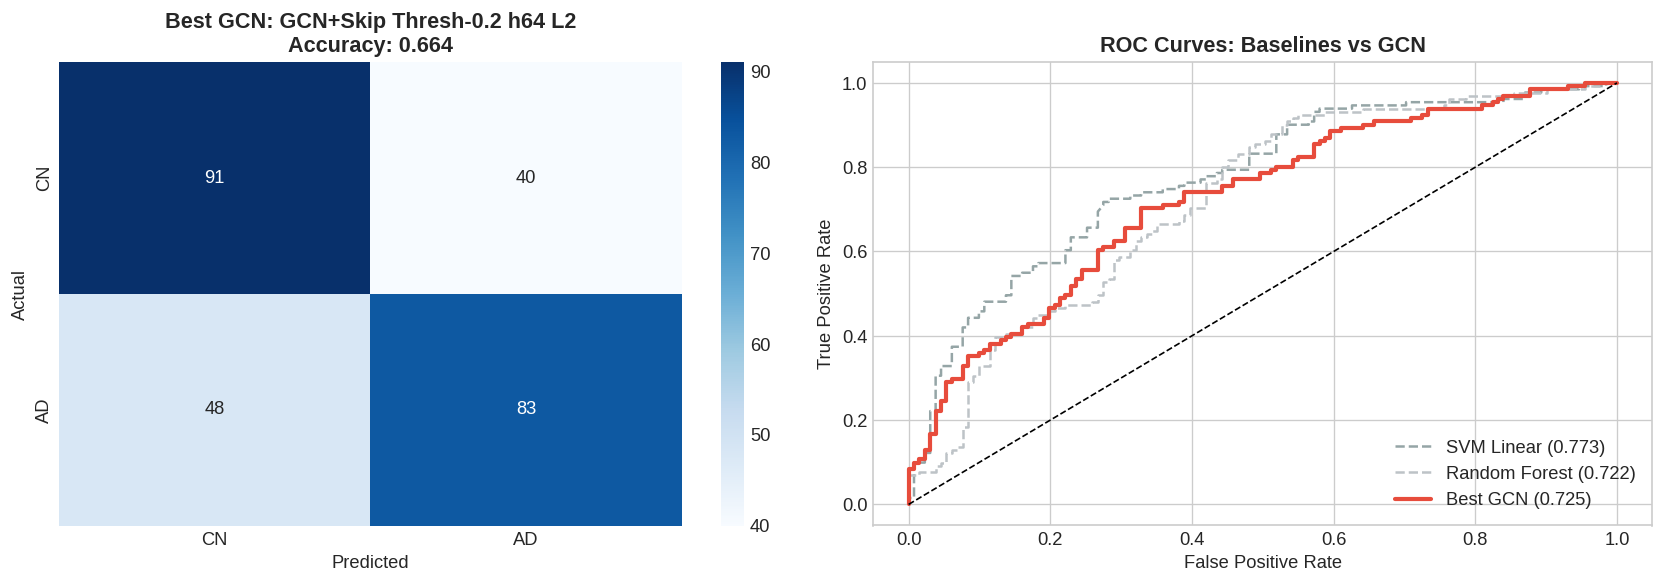

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(best_gcn['y_true_all'], best_gcn['y_pred_all'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['CN','AD'], yticklabels=['CN','AD'])
axes[0].set_title(f'Best GCN: {best_gcn["model_name"]}\nAccuracy: {best_gcn["accuracy_mean"]:.3f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

for nm, key, c, ls in [('SVM Linear','svm_linear','#95a5a6','--'),
                        ('Random Forest','random_forest','#bdc3c7','--')]:
    r = bl[key]; fpr,tpr,_ = roc_curve(r['y_true_all'], r['y_prob_all'])
    axes[1].plot(fpr,tpr,color=c,lw=1.5,ls=ls,label=f'{nm} ({auc(fpr,tpr):.3f})')
fpr,tpr,_ = roc_curve(best_gcn['y_true_all'], best_gcn['y_prob_all'])
axes[1].plot(fpr,tpr,color='#e74c3c',lw=2.5,label=f'Best GCN ({auc(fpr,tpr):.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves: Baselines vs GCN'); axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'gcn_cm_roc.png'))
plt.show()

### 7.4 Training Curves (Best GCN)

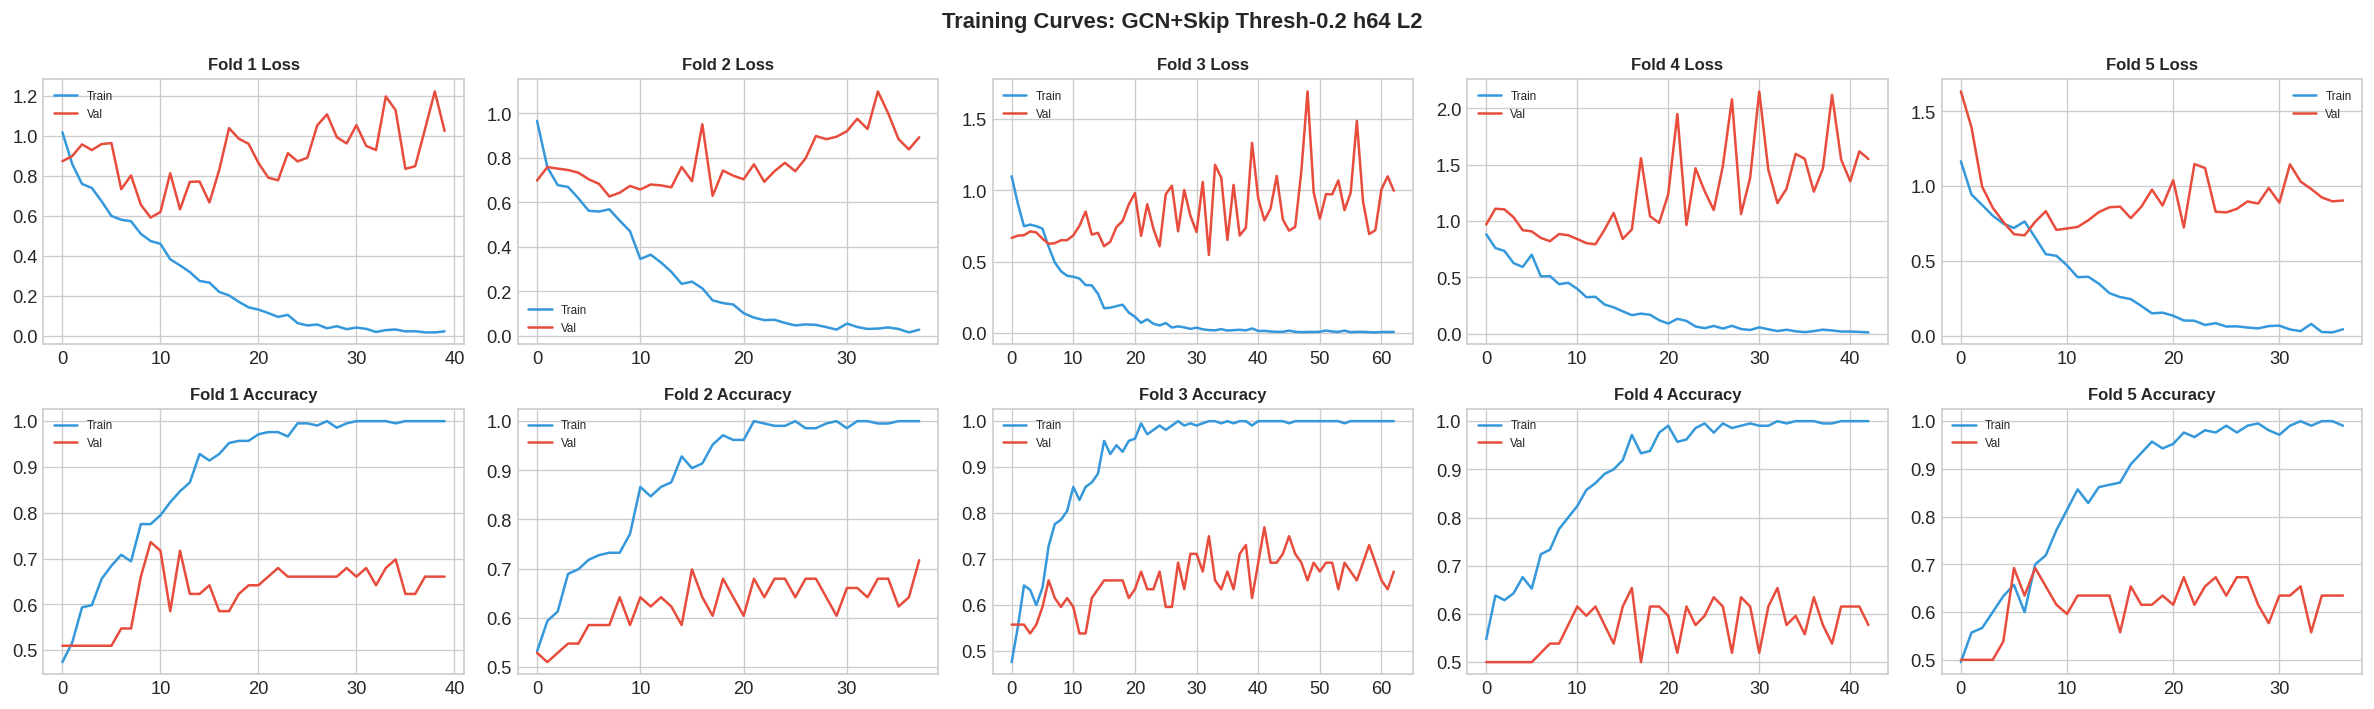

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, h in enumerate(best_gcn['fold_histories']):
    axes[0][i].plot(h['tl'],color='#3498db',label='Train')
    axes[0][i].plot(h['vl'],color='#e74c3c',label='Val')
    axes[0][i].set_title(f'Fold {i+1} Loss',fontsize=10); axes[0][i].legend(fontsize=7)
    axes[1][i].plot(h['ta'],color='#3498db',label='Train')
    axes[1][i].plot(h['va'],color='#e74c3c',label='Val')
    axes[1][i].set_title(f'Fold {i+1} Accuracy',fontsize=10); axes[1][i].legend(fontsize=7)
plt.suptitle(f'Training Curves: {best_gcn["model_name"]}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'gcn_training_curves.png'))
plt.show()

### 7.5 All Experiments Bar Chart

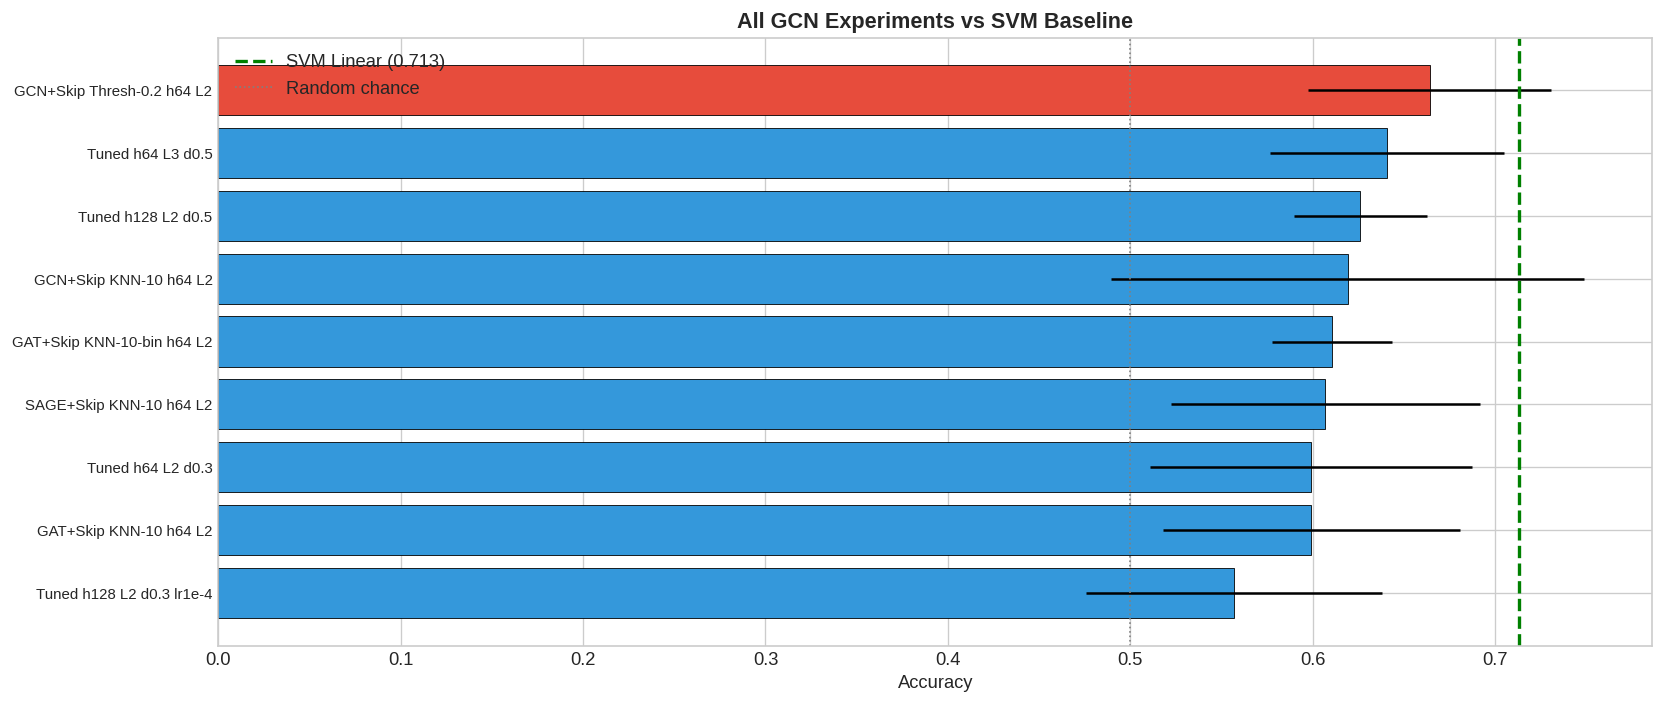

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
names = [r['model_name'] for r in all_results]
accs = [r['accuracy_mean'] for r in all_results]
stds = [r['accuracy_std'] for r in all_results]
colors = ['#e74c3c' if a==max(accs) else '#3498db' for a in accs]
ax.barh(range(len(names)), accs, xerr=stds, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
ax.axvline(x=bl['svm_linear']['accuracy_mean'], color='green', ls='--', lw=2,
           label=f'SVM Linear ({bl["svm_linear"]["accuracy_mean"]:.3f})')
ax.axvline(x=0.5, color='gray', ls=':', lw=1, label='Random chance')
ax.set_xlabel('Accuracy'); ax.set_title('All GCN Experiments vs SVM Baseline')
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(NB_FIGURES, 'gcn_all_experiments_bar.png'))
plt.show()

## 8. Save All Results

In [ ]:
# Save pickle
gcn_save = {'best':best_gcn, 'all_results':all_results,
            'n_experiments':len(all_results),
            'date':datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
pkl_path = os.path.join(NB_RESULTS, 'gcn_results.pkl')
with open(pkl_path,'wb') as f: pickle.dump(gcn_save, f)
print(f'Saved: {pkl_path}')

# Append to master CSV
summary_csv = os.path.join(RESULTS_BASE, 'all_results_summary.csv')
rows = [{'model_name':r['model_name'],'model_type':'gcn','n_subjects':r['n_subjects'],
         'accuracy_mean':f"{r['accuracy_mean']:.4f}",'accuracy_std':f"{r['accuracy_std']:.4f}",
         'f1_mean':f"{r['f1_mean']:.4f}",'f1_std':f"{r['f1_std']:.4f}",
         'auc_roc_mean':f"{r['auc_roc_mean']:.4f}",'auc_roc_std':f"{r['auc_roc_std']:.4f}",
         'time_seconds':f"{r['training_time_seconds']:.0f}",'notebook':'nb02_gcn',
         'date':r['date']} for r in all_results]
new_df = pd.DataFrame(rows)
if os.path.exists(summary_csv):
    existing = pd.read_csv(summary_csv)
    existing = existing[existing['notebook']!='nb02_gcn']
    combined = pd.concat([existing, new_df], ignore_index=True)
else: combined = new_df
combined.to_csv(summary_csv, index=False)
print(f'Saved: {summary_csv}')
display(combined.style.set_caption('Master Results Summary').hide(axis='index').\
        set_properties(**{'text-align':'center'}))

# Markdown report
rpt = os.path.join(NB_RESULTS, 'gcn_report.md')
with open(rpt, 'w') as f:
    f.write('# GCN Results Report (with Skip Connection)\n\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Experiments: {len(all_results)}\n')
    f.write(f'Key change: Skip connection per Keith feedback\n\n')
    f.write('| Rank | Model | Accuracy | F1 | AUC-ROC |\n')
    f.write('|------|-------|----------|-----|---------|\n')
    for i,r in enumerate(all_results):
        f.write(f'| {i+1} | {r["model_name"]} | {r["accuracy_mean"]:.4f}+/-{r["accuracy_std"]:.4f} | '
                f'{r["f1_mean"]:.4f}+/-{r["f1_std"]:.4f} | {r["auc_roc_mean"]:.4f}+/-{r["auc_roc_std"]:.4f} |\n')
    f.write(f'\nBaseline SVM Linear: {bl["svm_linear"]["accuracy_mean"]:.4f}\n')
    f.write(f'Best GCN: {best_gcn["accuracy_mean"]:.4f}\n')
print(f'Saved: {rpt}')

Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb02_gcn/gcn_results.pkl
Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/all_results_summary.csv


model_name,model_type,n_subjects,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_roc_mean,auc_roc_std,time_seconds,notebook,date
SVM (Linear),classical_ml,262,0.713400,0.057300,0.712600,0.057200,0.777100,0.051300,4.600000,nb01_baseline,2026-08-26 16:28:12
SVM (RBF),classical_ml,262,0.671500,0.056000,0.669700,0.055700,0.740500,0.076200,5.800000,nb01_baseline,2026-08-26 16:28:18
Random Forest,classical_ml,262,0.648500,0.058800,0.644500,0.059000,0.721100,0.059400,6.400000,nb01_baseline,2026-08-26 16:28:25
GCN+Skip Thresh-0.2 h64 L2,gcn,262,0.6642,0.0664,0.6532,0.0702,0.7401,0.0695,28,nb02_gcn,2026-08-26 16:38:39
Tuned h64 L3 d0.5,gcn,262,0.6409,0.0642,0.6118,0.1063,0.7144,0.0679,20,nb02_gcn,2026-08-26 16:40:12
Tuned h128 L2 d0.5,gcn,262,0.6262,0.0366,0.6220,0.0391,0.6706,0.0881,17,nb02_gcn,2026-08-26 16:39:52
GCN+Skip KNN-10 h64 L2,gcn,262,0.6192,0.1297,0.5377,0.1988,0.6719,0.1540,20,nb02_gcn,2026-08-26 16:38:11
GAT+Skip KNN-10-bin h64 L2,gcn,262,0.6107,0.0330,0.5797,0.0536,0.6752,0.0510,21,nb02_gcn,2026-08-26 16:39:21
SAGE+Skip KNN-10 h64 L2,gcn,262,0.6069,0.0847,0.5385,0.1665,0.6600,0.1095,14,nb02_gcn,2026-08-26 16:39:35
Tuned h64 L2 d0.3,gcn,262,0.5993,0.0883,0.5740,0.1118,0.6641,0.0918,17,nb02_gcn,2026-08-26 16:40:29


Saved: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb02_gcn/gcn_report.md


### 8.1 Summary

In [ ]:
n_figs = len([f for f in os.listdir(NB_FIGURES) if f.endswith('.png')])
imp = best_gcn['accuracy_mean'] - bl['svm_linear']['accuracy_mean']

print('='*55)
print('NOTEBOOK COMPLETE')
print('='*55)

final = pd.DataFrame({
    'Item': ['Experiments','Best Model','Best Accuracy','Best AUC-ROC',
             'vs SVM Linear','Figures Saved','Skip Connection'],
    'Value': [len(all_results), best_gcn['model_name'],
              f"{best_gcn['accuracy_mean']:.4f}+/-{best_gcn['accuracy_std']:.4f}",
              f"{best_gcn['auc_roc_mean']:.4f}+/-{best_gcn['auc_roc_std']:.4f}",
              f'{imp:+.4f} ({imp*100:+.1f}%)', n_figs, 'Yes (Keith feedback)']
})
display(final.style.set_caption('GCN Notebook Summary').hide(axis='index').\
        set_properties(**{'text-align':'left'}))

print(f'\nResults: {NB_RESULTS}')
print(f'  gcn_results.pkl | gcn_report.md | gcn_all_experiments.csv | {n_figs} figures')
print(f'\nNext: Notebook 3 - BiLSTM on raw BOLD temporal data')

NOTEBOOK COMPLETE


Item,Value
Experiments,9
Best Model,GCN+Skip Thresh-0.2 h64 L2
Best Accuracy,0.6642+/-0.0664
Best AUC-ROC,0.7401+/-0.0695
vs SVM Linear,-0.0492 (-4.9%)
Figures Saved,3
Skip Connection,Yes (Keith feedback)



Results: /content/drive/MyDrive/Kiran_Thesis/ADNI_preprocessed/DataPreparation/colab_package/results/nb02_gcn
  gcn_results.pkl | gcn_report.md | gcn_all_experiments.csv | 3 figures

Next: Notebook 3 - BiLSTM on raw BOLD temporal data
